#Scikit-Image

**For this assignment, I selected five distinct rocks from my collection. To maintain consistency, I photographed all of them under the same lighting conditions, in the same location, and on a white paper background. However, the rocks vary in size, which is an important factor to consider in the analysis.**

## Setup

### Import Libraries

In [11]:
# Import Libraries
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image
from io import BytesIO

### Import Data

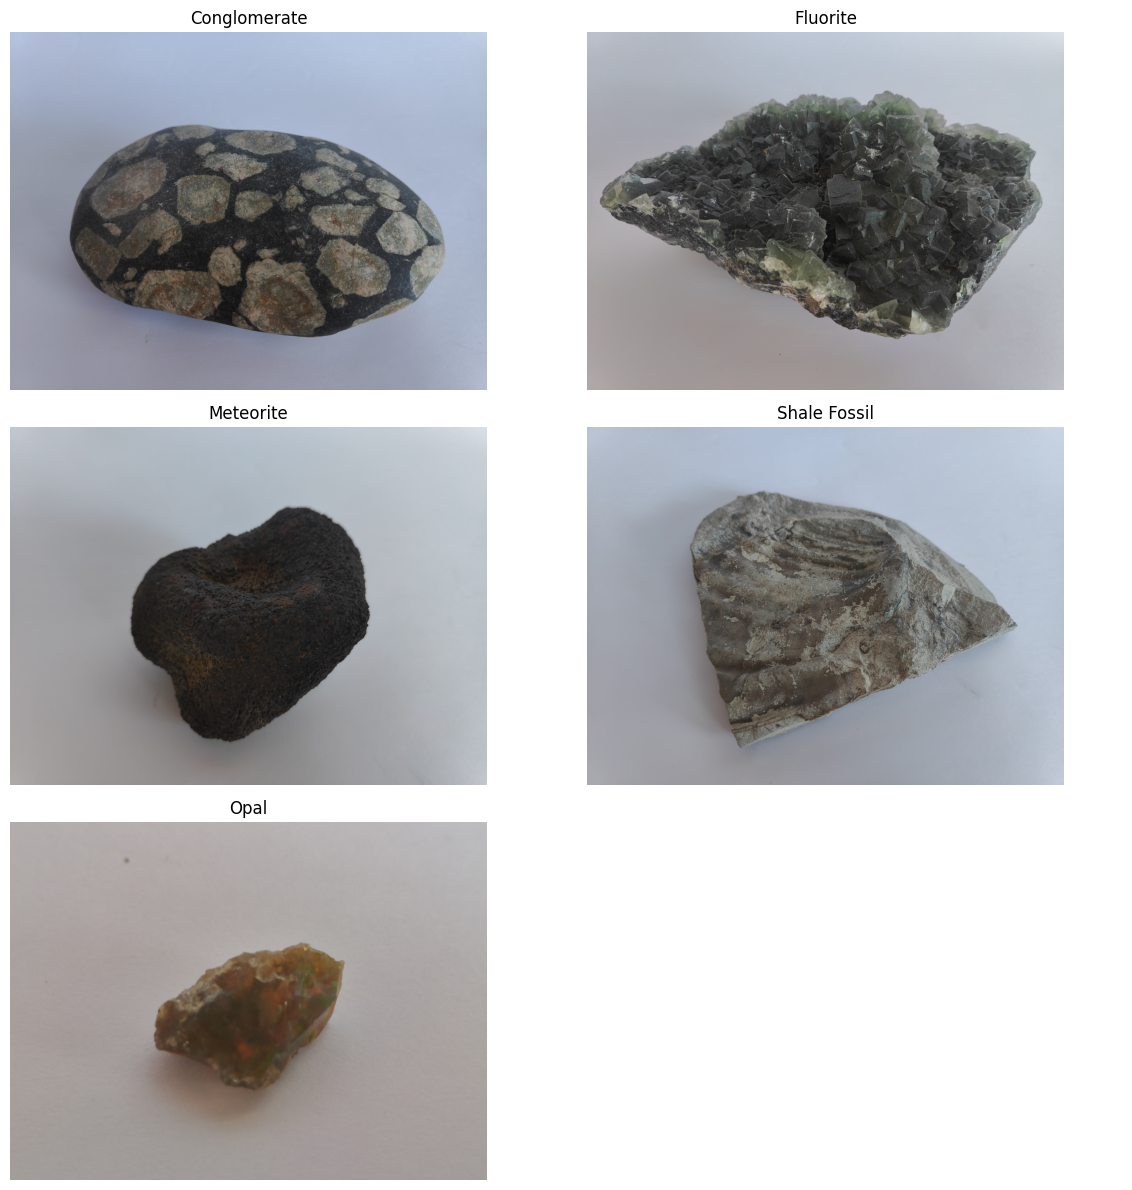

In [12]:
# Define GitHub raw file URLs
image_urls = {
    "conglomerate": "https://raw.githubusercontent.com/ed3894/GEOL-558A/main/Module%205/conglomerate.jpg",
    "fluorite": "https://raw.githubusercontent.com/ed3894/GEOL-558A/main/Module%205/fluorite.jpg",
    "meteorite": "https://raw.githubusercontent.com/ed3894/GEOL-558A/main/Module%205/meteorite.jpg",
    "shale_fossil": "https://raw.githubusercontent.com/ed3894/GEOL-558A/main/Module%205/shale_fossil.jpg",
    "opal": "https://raw.githubusercontent.com/ed3894/GEOL-558A/main/Module%205/opal.jpg"
}

# Fetch images and store them as individual NumPy arrays
image_arrays = {}

for name, url in image_urls.items():
    response = requests.get(url)
    if response.status_code == 200:
        img = Image.open(BytesIO(response.content))
        image_arrays[name] = np.array(img)  # Convert to NumPy array
    else:
        image_arrays[name] = None
        print(f"Failed to download {name}")

# Assign individual variables
conglomerate = image_arrays.get("conglomerate")
fluorite = image_arrays.get("fluorite")
meteorite = image_arrays.get("meteorite")
shale_fossil = image_arrays.get("shale_fossil")
opal = image_arrays.get("opal")

# Plot images in a 3x2 grid (since there are 5 images)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for ax, (name, img) in zip(axes.ravel(), image_arrays.items()):
    if img is not None:
        ax.imshow(img)
        ax.set_title(name.replace("_", " ").title())
    ax.axis("off")

# Hide any empty subplots if the number of images is less than the grid size
for i in range(len(image_arrays), len(axes.ravel())):
    axes.ravel()[i].axis("off")

plt.tight_layout()
plt.show()

## Scikit Examples

### Import Libraries

In [13]:
from skimage.color import rgb2hsv
from scipy import ndimage as ndi
from skimage import feature, color
from skimage.filters import unsharp_mask
from scipy.fft import fftn, fftshift
from scipy.signal.windows import hann
from skimage.filters import difference_of_gaussians
from skimage.color.adapt_rgb import adapt_rgb, each_channel, hsv_value
from skimage import filters, exposure

### RGB to HSV

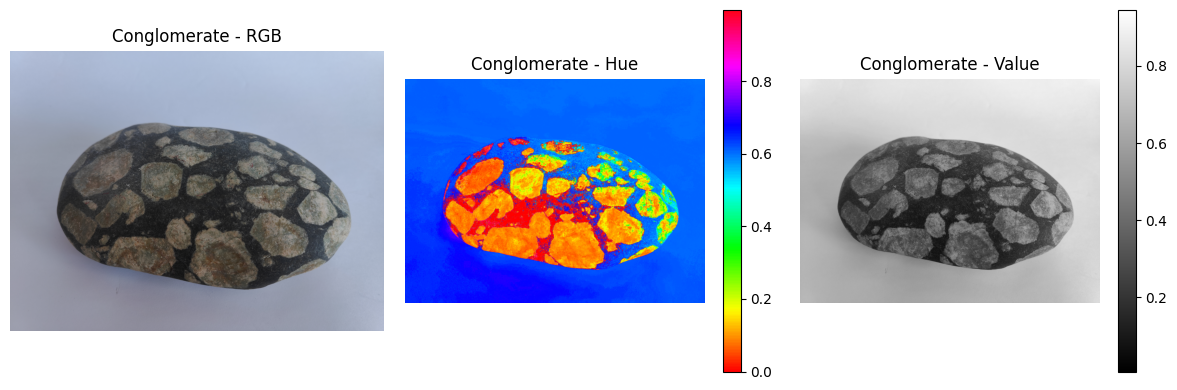

In [14]:
# Convert conglomerate image to HSV
conglomerate_hsv = rgb2hsv(conglomerate)
conglomerate_hue = conglomerate_hsv[:, :, 0]
conglomerate_value = conglomerate_hsv[:, :, 2]

# Create plots for conglomerate only
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

# RGB Image
axes[0].imshow(conglomerate)
axes[0].set_title("Conglomerate - RGB")
axes[0].axis('off')

# Hue Channel with Colorbar
im1 = axes[1].imshow(conglomerate_hue, cmap='hsv')
axes[1].set_title("Conglomerate - Hue")
axes[1].axis('off')
fig.colorbar(im1, ax=axes[1])

# Value Channel with Colorbar
im2 = axes[2].imshow(conglomerate_value, cmap='gray')
axes[2].set_title("Conglomerate - Value")
axes[2].axis('off')
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

**I applied RGB to HSV conversion to the conglomerate image to distinguish between the two dominant rock types. The results were promising—within the hue channel, the sediments appear closer to zero, while the cementing material is around 0.7, making their differences clear. However, the hue channel does not differentiate as well between the background and the cementing rock compared to the value channel, which provides a more distinct separation. In the value channel, the background is near 1, the sediments are around 0.6, and the cementing rock is closer to 0, effectively highlighting the composition of the rock.**

### Canny Edge Detector

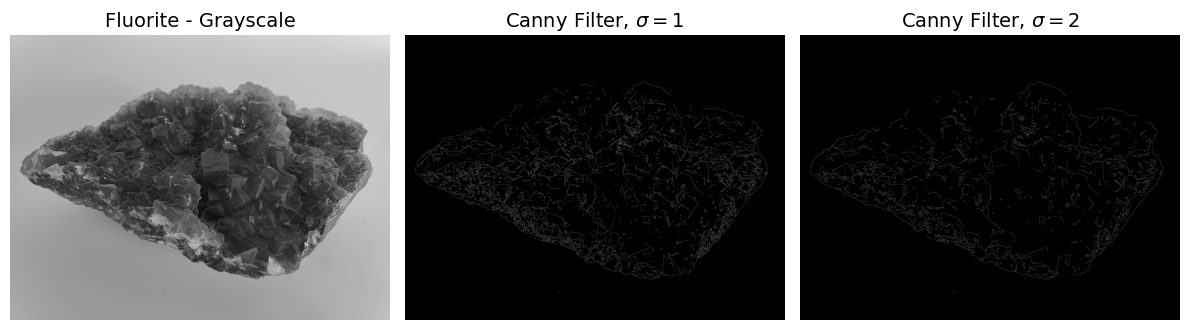

In [15]:
# Convert fluorite image to grayscale if it's in RGB
fluorite_gray = color.rgb2gray(fluorite)

# Apply Gaussian smoothing to reduce noise
fluorite_smoothed = ndi.gaussian_filter(fluorite_gray, 2)

# Compute the Canny edge filter for two values of sigma
edges1 = feature.canny(fluorite_smoothed, sigma=1)
edges2 = feature.canny(fluorite_smoothed, sigma=2)

# Display results
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

ax[0].imshow(fluorite_gray, cmap='gray')
ax[0].set_title('Fluorite - Grayscale', fontsize=14)

ax[1].imshow(edges1, cmap='gray')
ax[1].set_title(r'Canny Filter, $\sigma=1$', fontsize=14)

ax[2].imshow(edges2, cmap='gray')
ax[2].set_title(r'Canny Filter, $\sigma=2$', fontsize=14)

for a in ax:
    a.axis('off')

fig.tight_layout()
plt.show()

**Fluorite forms cubic crystal structures with distinct edges, which are clearly visible in the image. I applied the Canny edge detector to assess its ability to capture both the crystal edges and the boundary between the rock and the background. Overall, it performed well in distinguishing the rock from the background. I tested sigma values of 1 and 2—with sigma = 1, many extraneous features appeared, making the result noisier, while sigma = 2 provided a clearer representation of the crystal edges, effectively highlighting their structure.**

### Unsharp masking

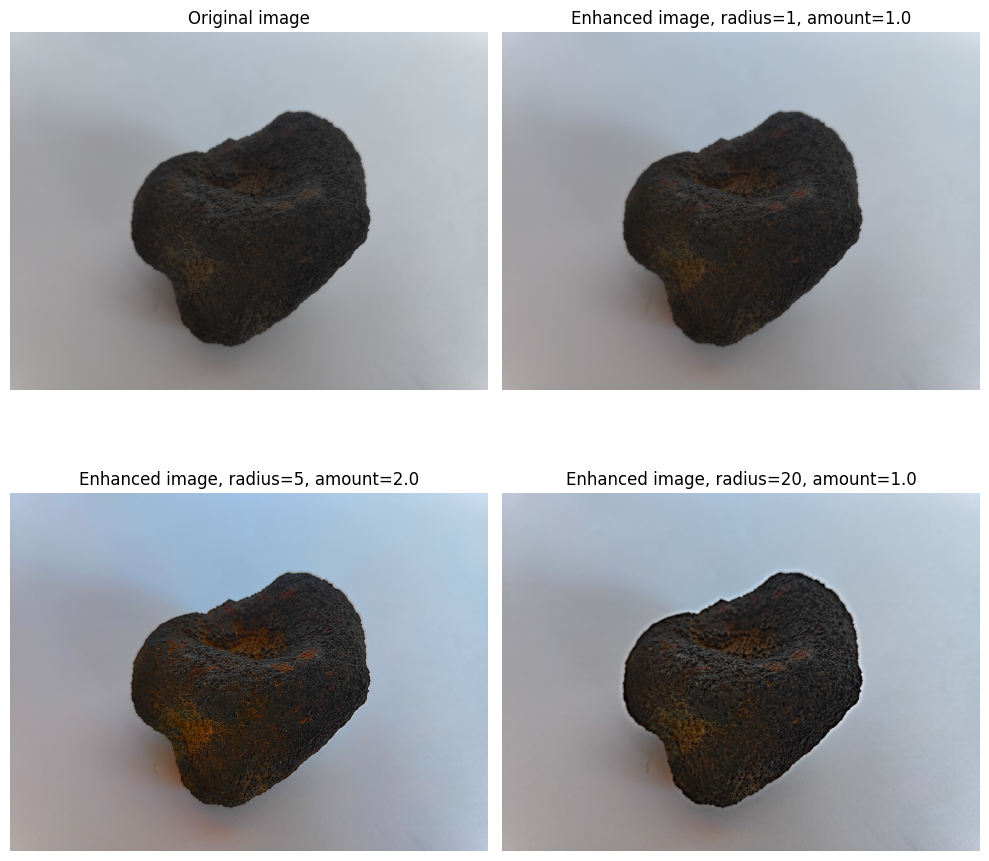

In [16]:
# Apply unsharp masking to enhance edges in meteorite image
result_1 = unsharp_mask(meteorite, radius=1, amount=1)
result_2 = unsharp_mask(meteorite, radius=5, amount=2)
result_3 = unsharp_mask(meteorite, radius=20, amount=1)

# Create subplots for visualization
fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(10, 10))
ax = axes.ravel()

ax[0].imshow(meteorite, cmap=plt.cm.gray)
ax[0].set_title('Original image')
ax[1].imshow(result_1, cmap=plt.cm.gray)
ax[1].set_title('Enhanced image, radius=1, amount=1.0')
ax[2].imshow(result_2, cmap=plt.cm.gray)
ax[2].set_title('Enhanced image, radius=5, amount=2.0')
ax[3].imshow(result_3, cmap=plt.cm.gray)
ax[3].set_title('Enhanced image, radius=20, amount=1.0')

for a in ax:
    a.axis('off')

fig.tight_layout()
plt.show()

**Meteorites, like this one, contain chondrules, which are the grain-like structures on the surface. However, the image resolution wasn’t high enough to capture them in fine detail. To enhance the texture, I applied unsharp masking with three different parameter sets. Radius 1 and amount 1 had minimal impact, providing little improvement. Radius 5 and amount 2 was more effective, revealing surface features like areas of rusting. Radius 20 and amount 1 brought out the most detail in the texture but at the cost of losing some of the color variations, including the rusted areas.**

### Band-pass filtering by Difference of Gaussians

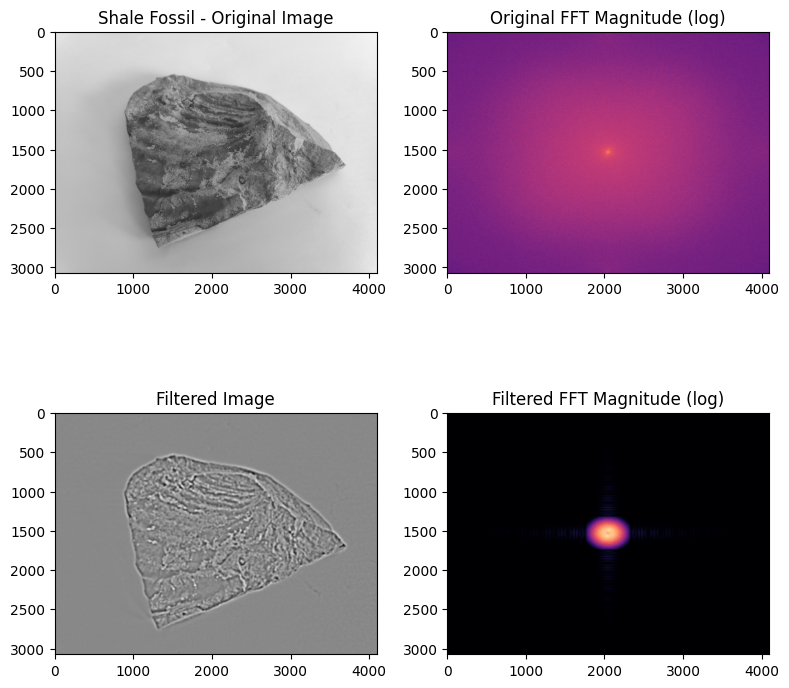

In [17]:
# Apply Hanning window function
def apply_window(image):
    return image * hann(image.shape[0])[:, None] * hann(image.shape[1])

# Convert shale_fossil image to grayscale if it's in RGB
shale_fossil_gray = np.mean(shale_fossil, axis=-1) if shale_fossil.ndim == 3 else shale_fossil

# Apply Hanning window to improve FFT
wimage = apply_window(shale_fossil_gray)

# Apply Difference of Gaussians filter
filtered_image = difference_of_gaussians(shale_fossil_gray, 10)
filtered_wimage = apply_window(filtered_image)

# Compute FFT magnitudes
im_f_mag = fftshift(np.abs(fftn(wimage)))
fim_f_mag = fftshift(np.abs(fftn(filtered_wimage)))

# Plot results
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

ax[0, 0].imshow(shale_fossil_gray, cmap='gray')
ax[0, 0].set_title('Shale Fossil - Original Image')

ax[0, 1].imshow(np.log(im_f_mag + 1), cmap='magma')  # +1 to avoid log(0) issues
ax[0, 1].set_title('Original FFT Magnitude (log)')

ax[1, 0].imshow(filtered_image, cmap='gray')
ax[1, 0].set_title('Filtered Image')

ax[1, 1].imshow(np.log(fim_f_mag + 1), cmap='magma')  # +1 to avoid log(0) issues
ax[1, 1].set_title('Filtered FFT Magnitude (log)')

plt.tight_layout()
plt.show()

**This image features a clam fossil embedded within a layered shale formation. I applied band-pass filtering using the Difference of Gaussians to enhance the structural details of the fossil. Overall, this method performed well, effectively highlighting the ripples and fine textures of the fossil. Additionally, it provided a clear distinction between the fossil and the surrounding shale, as well as a sharp boundary between the rock sample and the background.**

### Sobel Filters on RGB and HSV

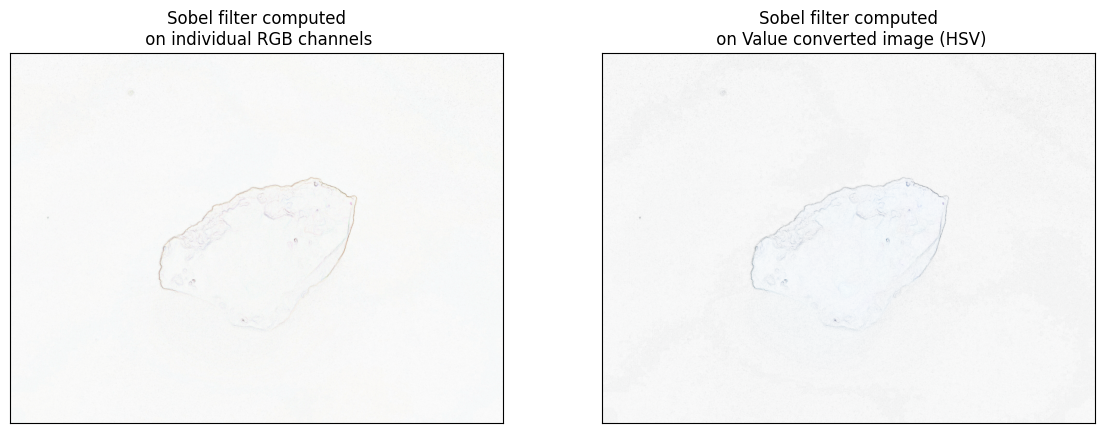

In [18]:
# Define Sobel filter functions
@adapt_rgb(each_channel)
def sobel_each(image):
    return filters.sobel(image)

@adapt_rgb(hsv_value)
def sobel_hsv(image):
    return filters.sobel(image)

# Apply Sobel filtering to opal image
fig, (ax_each, ax_hsv) = plt.subplots(ncols=2, figsize=(14, 7))

# Apply Sobel to each RGB channel
ax_each.imshow(exposure.rescale_intensity(1 - sobel_each(opal)), cmap='gray')
ax_each.set_xticks([]), ax_each.set_yticks([])
ax_each.set_title("Sobel filter computed\n on individual RGB channels")

# Apply Sobel to HSV (Value) channel
ax_hsv.imshow(exposure.rescale_intensity(1 - sobel_hsv(opal)), cmap='gray')
ax_hsv.set_xticks([]), ax_hsv.set_yticks([])
ax_hsv.set_title("Sobel filter computed\n on Value converted image (HSV)")

plt.show()

**For the opal sample, I wanted to see if I could differentiate the edges and identify any internal structures. The original opal image displays varied surface colors, and I thought applying the Sobel filter to both the RGB and HSV representations could help highlight these variations. Overall, the filter effectively captured the sample's outer edges, but it was less effective in distinguishing the subtle surface textures, mineral patterns, and internal features within the opal.**

### Reflection (word count: 178)

**This assignment was engaging and made me think critically about how each method applies to different rock samples. In machine learning, especially for training image-based models, adding new dimensions beyond the raw image can be valuable. Techniques like converting to hue and value channels or applying Canny edge detection help extract meaningful features. Another key goal is background removal, which Sobel filters and band-pass filtering with the Difference of Gaussians handled well. Eliminating the background ensures the model focuses solely on the rock itself, improving its accuracy and relevance.**

**For example, if you want to differentiate minerals, color may be a crucial factor since many share similar cubic crystal structures. Adding higher-dimensional features can significantly improve classification, as a single image provides only limited information. However, adding dimensions randomly can degrade model performance, making it essential to ground feature selection in geological principles. Some methods, like unsharp masking, may sharpen textures but at the cost of losing color information. There is no perfect procedure—choices should align with the geology of the sample and the goals of the investigation. I appreciated these methods for their ease of implementation and short runtimes, though scalability could be a concern when working with large datasets.**